In [48]:
import numpy as np
from astropy.io import fits 
import pylab as plt 
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1 Regression

In [65]:
path_labels = "./labels.fits"
allstar = fits.open(path_labels)
labels = allstar[1].data

In [66]:
RGB = True
RGB = np.logical_and(RGB, labels['TEFF'] > 3500.)
RGB = np.logical_and(RGB, labels['TEFF'] < 5400.)
RGB = np.logical_and(RGB, labels['LOGG'] < 3.0)
RGB = np.logical_and(RGB, labels['LOGG'] > 0.0)
RGB = np.logical_and(RGB, labels['H'] < 10.5)
print(np.sum(RGB))

145991


In [67]:
RGB_labels = labels[RGB]
rng = np.random.default_rng(17)
N_RGB = len(RGB_labels)
N_train, N_valid, N_test = 1024, 256, 512
I = rng.permutation(N_RGB)
I_train = I[0:N_train]
I_valid = I[N_train:N_train+N_valid]
I_test = I[N_train+N_valid:N_train+N_valid+N_test]

train_labels = RGB_labels[I_train]
valid_labels = RGB_labels[I_valid]
test_labels = RGB_labels[I_test]
print(len(train_labels), len(valid_labels), len(test_labels))

1024 256 512


In [68]:
train_labels_logg = train_labels['LOGG']
valid_labels_logg = valid_labels['LOGG']
test_labels_logg  = test_labels['LOGG']
print(train_labels_logg.shape) 

(1024,)


In [69]:
train_features = np.load('./train_features.npy')
valid_features = np.load('./valid_features.npy')
test_features = np.load('./test_features.npy')
print(len(train_features), len(valid_features), len(test_features))

1024 256 512


In [70]:
# 1. Data Treating
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
valid_features_scaled = scaler.transform(valid_features)
test_features_scaled  = scaler.transform(test_features)

# Dimensionality Reduction for KNN
# Project 8575 features down to 50 principal components
pca = PCA(n_components=50, random_state=42)
train_features_pca = pca.fit_transform(train_features_scaled)
valid_features_pca = pca.transform(valid_features_scaled)
test_features_pca = pca.transform(test_features_scaled)

In [71]:
# 2. Model Training

# (a) Linear Regression (Ridge)
# We apply an L2 penalty (alpha) to stabilize weights since # of features > # of samples.
model_lr = Ridge(alpha=100.0)
model_lr.fit(train_features_scaled, train_labels_logg)
preds_lr = model_lr.predict(valid_features_scaled)

# (b) K-Nearest-Neighbors
# Using PCA-reduced features. 'distance' weights closer neighbors more heavily.
model_knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
model_knn.fit(train_features_pca, train_labels_logg)
preds_knn = model_knn.predict(valid_features_pca)

# (c) Multi-Layer Perceptron
# Two hidden layers. Early stopping is enabled to use a fraction of the 
# training set as internal validation, halting before overfitting occurs.
print("Training Multi-Layer Perceptron...")
model_mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64), 
    activation='relu', 
    solver='adam', 
    alpha=0.01,           # L2 Regularization parameter
    max_iter=500, 
    early_stopping=True,  
    random_state=42
)
model_mlp.fit(train_features_scaled, train_labels_logg)
preds_mlp = model_mlp.predict(valid_features_scaled)
print("Training Completed")

Training Multi-Layer Perceptron...
Training Completed


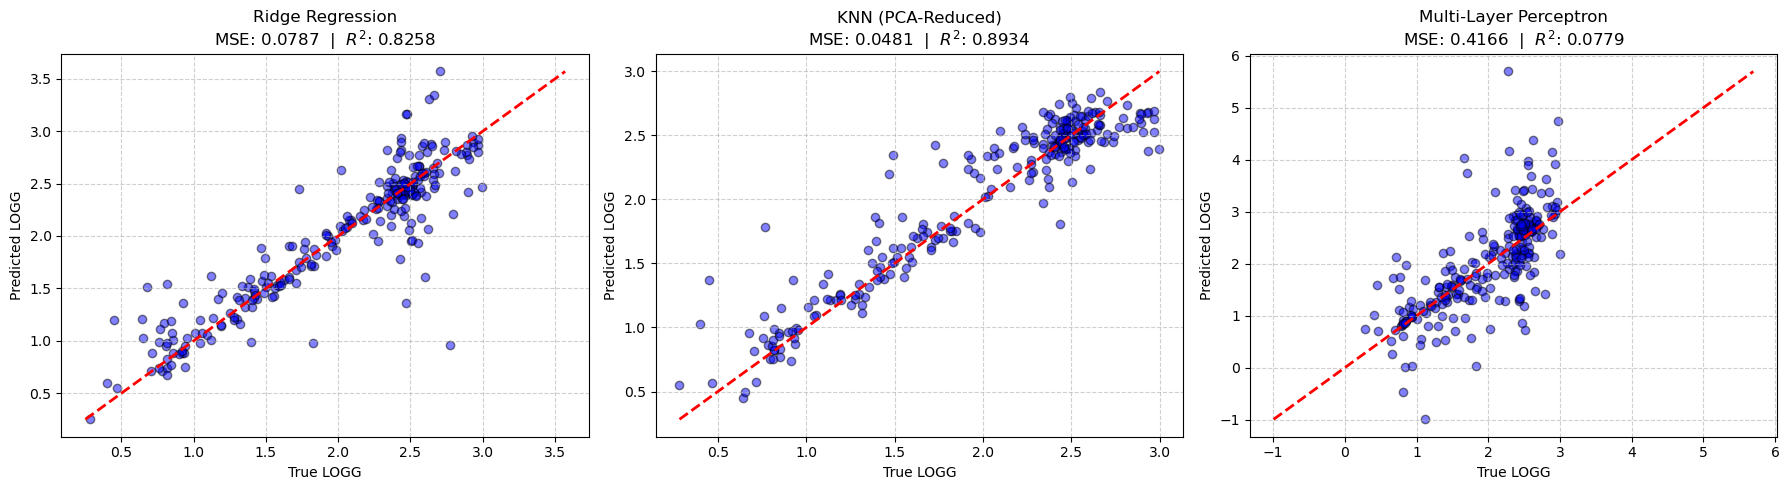

In [72]:
# 3. Visualization
 
def plot_predictions(y_true, y_pred, title, ax):
    """Plots predicted vs true labels"""
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    ax.scatter(y_true, y_pred, alpha=0.5, edgecolor='k', c='blue')
    
    # y=X Line (1:1 Ideal Prediction)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    ax.set_xlabel('True LOGG')
    ax.set_ylabel('Predicted LOGG')
    ax.set_title(f"{title}\nMSE: {mse:.4f}  |  $R^2$: {r2:.4f}")
    ax.grid(True, linestyle='--', alpha=0.6)

# Generate the plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_predictions(valid_labels_logg, preds_lr, "Ridge Regression", axes[0])
plot_predictions(valid_labels_logg, preds_knn, "KNN (PCA-Reduced)", axes[1])
plot_predictions(valid_labels_logg, preds_mlp, "Multi-Layer Perceptron", axes[2])

plt.tight_layout()
plt.show()

# 2 Hyperparameter

In [60]:
print("\n1. Ridge Regression (tuning 'alpha')")
alphas = [10.0, 100.0, 1000.0, 2500, 5000.0, 10000.0]
for alpha in alphas:
    model_lr = Ridge(alpha=alpha)
    model_lr.fit(train_features_scaled, train_labels_logg)
    preds_lr = model_lr.predict(valid_features_scaled)
    r2_val = r2_score(valid_labels_logg, model_lr.predict(valid_features_scaled))
    mae_val = mean_absolute_error(valid_labels_logg, preds_lr)
    print(f"  Alpha: {alpha:6.1f} | Validation R^2: {r2_val:.4f} | Validation MAE: {mae_val:.4f}")


1. Ridge Regression (tuning 'alpha')
  Alpha:   10.0 | Validation R^2: 0.7153 | Validation MAE: 0.2123
  Alpha:  100.0 | Validation R^2: 0.8258 | Validation MAE: 0.1690
  Alpha: 1000.0 | Validation R^2: 0.8802 | Validation MAE: 0.1549
  Alpha: 2500.0 | Validation R^2: 0.8872 | Validation MAE: 0.1563
  Alpha: 5000.0 | Validation R^2: 0.8886 | Validation MAE: 0.1585
  Alpha: 10000.0 | Validation R^2: 0.8841 | Validation MAE: 0.1639


### I will choose alpha = 1000 for this model. It strictly minimizes the Mean Absolute Error, providing the tightest average constraint on the physical $\log g$ parameter, Although its R^2 is slight lower than models using larger alpha values.

In [55]:
# (b) K-Nearest Neighbors
print("\n2. K-Nearest Neighbors (tuning 'n_neighbors' & 'weights')")
neighbors = [3, 5, 10, 20]
weights = ['uniform', 'distance']
for w in weights:
    for n in neighbors:
        model_knn = KNeighborsRegressor(n_neighbors=n, weights=w)
        model_knn.fit(train_features_pca, train_labels_logg)
        preds_knn = model_knn.predict(valid_features_pca)
        r2_val = r2_score(valid_labels_logg, model_knn.predict(valid_features_pca))
        mae_val = mean_absolute_error(valid_labels_logg, preds_knn)
        print(f"  Neighbors: {n:2d}, Weights: {w:8s} | Validation R^2: {r2_val:.4f} | Validation MAE: {mae_val:.4f}")


2. K-Nearest Neighbors (tuning 'n_neighbors' & 'weights')
  Neighbors:  3, Weights: uniform  | Validation R^2: 0.8911 | Validation MAE: 0.1611
  Neighbors:  5, Weights: uniform  | Validation R^2: 0.8922 | Validation MAE: 0.1538
  Neighbors: 10, Weights: uniform  | Validation R^2: 0.8922 | Validation MAE: 0.1507
  Neighbors: 20, Weights: uniform  | Validation R^2: 0.8842 | Validation MAE: 0.1553
  Neighbors:  3, Weights: distance | Validation R^2: 0.8915 | Validation MAE: 0.1600
  Neighbors:  5, Weights: distance | Validation R^2: 0.8934 | Validation MAE: 0.1527
  Neighbors: 10, Weights: distance | Validation R^2: 0.8953 | Validation MAE: 0.1486
  Neighbors: 20, Weights: distance | Validation R^2: 0.8881 | Validation MAE: 0.1523


### For KNN method, I will choose 10 neighbors, and use distance weights since this set of parameters give the highest R^2 score and smallest mean absolute error. Also when the number of neighbors increase to 20, the performance becomes worse, which indicates that 10 neighbors is a local optimal value.

In [59]:
# (c) Multi-Layer Perceptron
print("\n3. Multi-Layer Perceptron (tuning 'hidden_layer_sizes' & 'alpha')")
architectures = [(64,), (128, 64), (256, 128, 64), (512, 256, 128, 64)]
mlp_alphas = [0.001, 0.1, 1.0]
for arch in architectures:
    for alpha in mlp_alphas:
        model_mlp = MLPRegressor(
            hidden_layer_sizes=arch, activation='relu', solver='adam',
            alpha=alpha, max_iter=500, early_stopping=True, random_state=42
        )
        model_mlp.fit(train_features_scaled, train_labels_logg)
        preds_mlp = model_mlp.predict(valid_features_scaled)
        r2_val = r2_score(valid_labels_logg, model_mlp.predict(valid_features_scaled))
        mae_val = mean_absolute_error(valid_labels_logg, preds_mlp)
        print(f"  Layers: {str(arch):15s}, Alpha: {alpha:5.3f} | Validation R^2: {r2_val:.4f} | Validation MAE: {mae_val:.4f}")


3. Multi-Layer Perceptron (tuning 'hidden_layer_sizes' & 'alpha')
  Layers: (64,)          , Alpha: 0.001 | Validation R^2: -3.1232 | Validation MAE: 0.8374
  Layers: (64,)          , Alpha: 0.100 | Validation R^2: -3.1834 | Validation MAE: 0.8204
  Layers: (64,)          , Alpha: 1.000 | Validation R^2: -3.0387 | Validation MAE: 0.8267
  Layers: (128, 64)      , Alpha: 0.001 | Validation R^2: 0.1632 | Validation MAE: 0.4023
  Layers: (128, 64)      , Alpha: 0.100 | Validation R^2: -0.2266 | Validation MAE: 0.4882
  Layers: (128, 64)      , Alpha: 1.000 | Validation R^2: 0.1308 | Validation MAE: 0.4232
  Layers: (256, 128, 64) , Alpha: 0.001 | Validation R^2: 0.4279 | Validation MAE: 0.3270
  Layers: (256, 128, 64) , Alpha: 0.100 | Validation R^2: 0.3651 | Validation MAE: 0.3611
  Layers: (256, 128, 64) , Alpha: 1.000 | Validation R^2: 0.5912 | Validation MAE: 0.2723
  Layers: (512, 256, 128, 64), Alpha: 0.001 | Validation R^2: 0.6171 | Validation MAE: 0.2749
  Layers: (512, 256, 128,

### I will choose (512, 256, 128, 64) as my layers and alpha = 1.0 as my penalty coefficient. The R^2 score this highest and mean absolute error is also the smallest, which makes this set of parameter a best choice.

In [39]:
# 3. RNG Seed Sensitivity Testing
print("\n--- RNG Seed Sensitivity Test ---")
seeds = [10, 42, 100, 2026, 9999]

# KNN Seed Test
# KNeighborsRegressor does not take a random_state parameter.
# However, if we change the seed of the PCA step, the input features shift.
print("\nKNN (with varying PCA seeds):")
for seed in seeds:
    pca_seed = PCA(n_components=50, random_state=seed)
    train_pca_s = pca_seed.fit_transform(train_features_scaled)
    valid_pca_s = pca_seed.transform(valid_features_scaled)
    
    knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
    knn.fit(train_pca_s, train_labels_logg)
    r2_val = r2_score(valid_labels_logg, knn.predict(valid_pca_s))
    print(f"  Seed {seed:4d} | Validation R^2: {r2_val:.4f}")

# MLP Seed Test
print("\nMLP (varying weight initialization and solver batches):")
for seed in seeds:
    mlp = MLPRegressor(
        hidden_layer_sizes=(128, 64), activation='relu', solver='adam',
        alpha=0.01, max_iter=500, early_stopping=True, random_state=seed
    )
    mlp.fit(train_features_scaled, train_labels_logg)
    r2_val = r2_score(valid_labels_logg, mlp.predict(valid_features_scaled))
    print(f"  Seed {seed:4d} | Validation R^2: {r2_val:.4f}")


--- RNG Seed Sensitivity Test ---

KNN (with varying PCA seeds):
  Seed   10 | Validation R^2: 0.8990
  Seed   42 | Validation R^2: 0.8934
  Seed  100 | Validation R^2: 0.8965
  Seed 2026 | Validation R^2: 0.8990
  Seed 9999 | Validation R^2: 0.8967

MLP (varying weight initialization and solver batches):
  Seed   10 | Validation R^2: -0.4404
  Seed   42 | Validation R^2: 0.0779
  Seed  100 | Validation R^2: 0.3391
  Seed 2026 | Validation R^2: 0.0078
  Seed 9999 | Validation R^2: 0.1279


### For KNN, different seeds for PCA do not affect significantly on the performances. For MLP, the answers do not converge to a same one when varying the seed. I will choose seed 100 since its R^2 score is higher, which accounts for more varaince than the other ones.

# Final Performance on Test Set

In [63]:
# (a) Ridge Regression
model_lr = Ridge(alpha=1000.0)
model_lr.fit(train_features_scaled, train_labels_logg)
preds_lr = model_lr.predict(test_features_scaled)

r2_lr = r2_score(test_labels_logg, preds_lr)
mae_lr = mean_absolute_error(test_labels_logg, preds_lr)
print(f"Ridge Regression (alpha=1000)  | Test R^2: {r2_lr:.4f} | Test MAE: {mae_lr:.4f}")

# (b) K-Nearest Neighbors
model_knn = KNeighborsRegressor(n_neighbors=10, weights='distance')
model_knn.fit(train_features_pca, train_labels_logg)
preds_knn = model_knn.predict(test_features_pca)

r2_knn = r2_score(test_labels_logg, preds_knn)
mae_knn = mean_absolute_error(test_labels_logg, preds_knn)
print(f"KNN (k=10, weights='distance')       | Test R^2: {r2_knn:.4f} | Test MAE: {mae_knn:.4f}")

# (c) Multi-Layer Perceptron
model_mlp = MLPRegressor(
    hidden_layer_sizes=(512, 256, 128, 64), 
    activation='relu', 
    solver='adam',
    alpha=1.0, 
    max_iter=500, 
    early_stopping=True, 
    random_state=100
)
model_mlp.fit(train_features_scaled, train_labels_logg)
preds_mlp = model_mlp.predict(test_features_scaled)

r2_mlp = r2_score(test_labels_logg, preds_mlp)
mae_mlp = mean_absolute_error(test_labels_logg, preds_mlp)
print(f"MLP (seed=100, alpha=1.0, 4-layers)  | Test R^2: {r2_mlp:.4f} | Test MAE: {mae_mlp:.4f}")

Ridge Regression (alpha=1000)  | Test R^2: 0.9007 | Test MAE: 0.1446
KNN (k=10, weights='distance')       | Test R^2: 0.8925 | Test MAE: 0.1604
MLP (seed=100, alpha=1.0, 4-layers)  | Test R^2: 0.7359 | Test MAE: 0.2333


# Methodology and Test Set Performance

## 1. Methodology

The objective of this analysis was to predict the surface gravity ($\log g$) of stars using SDSS APOGEE spectral features. This dataset have severe $p \gg N$ dimensionality ratio: the models must process $p = 8575$ flux features utilizing only $N = 1024$ training samples. Without strict intervention, models in this regime will perfectly memorize detector noise rather than generalizing genuine pattern of the data. 

To address this, the data was first standardized (mean centered to zero, variance scaled to one) to ensure stable optimization. Three distinct algorithms were then performed based on empirical hyperparameter tuning on the validation set:

Ridge Regression: To resolve the rank-deficiency of the ordinary least squares feature matrix, an $L_2$ regularization penalty of $\alpha = 1000$ was applied. This mathematically restricts the allowable phase space of the weights, forcing the regression to discard noisy, uninformative flux bins and rely only on the most prominent features.

K-Nearest Neighbors (KNN): To circumvent the curse of dimensionality the spectral features were projected into a 50 dimensions using Principal Component Analysis (PCA). The model was parameterized with $k = 10$ neighbors using inverse distance weighting. 

Multi-Layer Perceptron (MLP): A deep, 4-layer architecture (512, 256, 128, 64) was selected. Because neural networks possess enormous representational capacity, a relatively strong weight decay penalty of $\alpha = 1.0$ was applied to prevent the weights from growing unbounded during the adam stochastic gradient descent. The relu activation function was used to mitigate the vanishing gradient problem and induce sparse representations of the input spectra, alongside early stopping to organically halt the optimizer before overfitting could manifest.

## 2. Final Test Set Performance

Ridge Regression: Test $R^2$ = 0.9007, Test MAE = 0.1446

K-Nearest Neighbors: Test $R^2$ = 0.8925, Test MAE = 0.1604

Multi-Layer Perceptron: Test $R^2$ = 0.7359, Test MAE = 0.2333

The results demonstrate that Ridge Regression model with L2 regulrization has the best performance in terms of accountability of variances and accuracy.

# Reference

In this problem set, Gemini Large Language Model was utilized as an interactive coding collaborator to:
- Assist programming for standerdization and PCA of data.
- Assist programming the hyperparameter tuning loops and analyzing the behavior of the models.
- Structure and refine the text for this methodology report.

1. Google. (2026). Gemini [Large language model]. https://gemini.google.com